<h2 style="
background-color:#F8D7DA;
color:black;
padding:10px;
border-radius:8px;
font-weight:bold;
font-style:italic;
">
Task 6 : Hypothesis Testing
</h2>

In [5]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("cleaned_jp_morgan.csv")

In [7]:
from scipy.stats import ttest_ind

**<h3 style="color:blue;"> 6.2 Test whether high-volume transaction accounts have statistically higher average balances than low-volume accounts.</h>**


P-value: 0.5500
Conclusion: Not Significant. No evidence of higher balances in high-volume accounts.


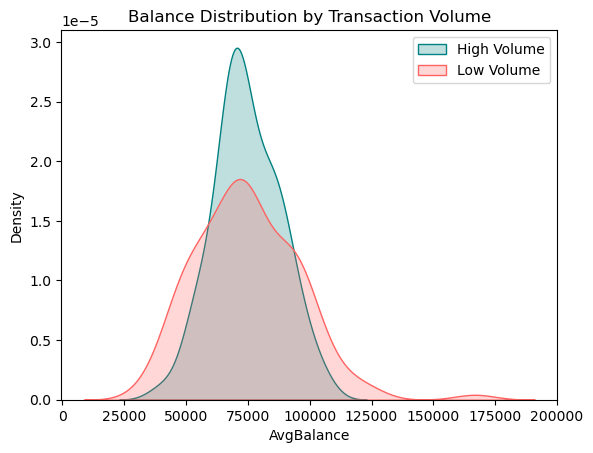

In [13]:
# Group by account to get Volume and Average Balance
acct_stats = df.groupby('AccountID').agg(
    TransVolume=('AccountID', 'count'),
    AvgBalance=('AccountBalance', 'mean')
).reset_index()

# Split into High and Low volume groups using the median
median_vol = acct_stats['TransVolume'].median()
high_vol = acct_stats[acct_stats['TransVolume'] > median_vol]['AvgBalance']
low_vol = acct_stats[acct_stats['TransVolume'] <= median_vol]['AvgBalance']

# Perform Welch's T-Test (one-sided for "higher")
t_stat, p_val = stats.ttest_ind(high_vol, low_vol, equal_var=False, alternative='greater')

# Print Results
print(f"P-value: {p_val:.4f}")
if p_val < 0.05:
    print("Conclusion: Statistically Significant. High-volume accounts have higher balances.")
else:
    print("Conclusion: Not Significant. No evidence of higher balances in high-volume accounts.")

# Visualization
sns.kdeplot(high_vol, fill=True, label='High Volume', color='teal')
sns.kdeplot(low_vol, fill=True, label='Low Volume', color='#ff6361')
plt.title("Balance Distribution by Transaction Volume")
plt.legend()
plt.show()

**<h3 style="color:blue;">6.3 Conduct hypothesis testing based on segmentation.</h>**

In [15]:
# Calculate Volume and Avg Balance per account
segment_df = df.groupby('AccountID').agg(
    Volume=('AccountID', 'count'),
    AvgBalance=('AccountBalance', 'mean')
).reset_index()

# Split segments by median
median_val = segment_df['Volume'].median()
high_vol = segment_df[segment_df['Volume'] > median_val]['AvgBalance']
low_vol = segment_df[segment_df['Volume'] <= median_val]['AvgBalance']

# Execute Welch's T-Test (one-tailed)
t_stat, p_val = stats.ttest_ind(high_vol, low_vol, equal_var=False, alternative='greater')

print(f"T-statistic: {t_stat:.4f}, P-value: {p_val:.4f}")

T-statistic: -0.1257, P-value: 0.5500
